# Frechet means with alpha-connections

The **exponential barycenter** (which is the generalization of the Frechet mean associated to an affine connection) is the point $\bar{x}$, solution of the following equation:

$$\frac{1}{N} \sum_{i=1}^N \log_{\bar{x}}^{(\alpha)}(x_i) = 0$$

where $\log^{(\alpha)}$ is the logarithm of the $\alpha$-connection

**Algorithm (gradient descent on the connection)** :
$$\bar{x}_{t+1} = \exp_{\bar{x}_t}^{(\alpha)}\!\left(\eta \cdot \frac{1}{N}\sum_i \log_{\bar{x}_t}^{(\alpha)}(x_i)\right)$$

For $\alpha = 0$ (Fisher-Rao connection), we must find that the Riemannian Frechet mean and the exponential barycenter calculated for this $\alpha$-connection are the same.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

import geomstats.backend as gs
import geomstats.visualization as visualization
from geomstats.information_geometry.normal import (
    UnivariateNormalAlpha,
    UnivariateNormalDistributions,
)
from geomstats.learning.exponential_barycenter import GeneralExponentialBarycenter
from geomstats.learning.frechet_mean import FrechetMean
from scipy.stats import norm

# Algorithms for simulations

## creation of the space with $\alpha$-connections

In [4]:
def make_alpha_space(alpha, riemannian_manifold):
    space = UnivariateNormalDistributions(equip=False)
    space.equip_with_connection(
        UnivariateNormalAlpha,
        riemannian_manifold=riemannian_manifold,
        alpha=alpha,
    )
    return space

## Analytic barycenters for $\alpha = -1$ and $\alpha = 1$

In [5]:
def barycenter_mix(points):
    mu_bar = 0 
    for i in range(len(points)):
        mu_bar += points[i][0]
    mu_bar /= len(points)
    sigma_bar = 0 
    for i in range(len(points)):
        sigma_bar += points[i][1]**2
    for i in range(len(points)):
        sigma_bar += (points[i][0] - mu_bar)**2
    sigma_bar /= len(points)
    sigma_bar = np.sqrt(sigma_bar)
    return mu_bar, sigma_bar

def barycenter_exponential(points):
    denominator = 0
    sigma_bar = 0
    for i in range(len(points)):
        denominator += 1/points[i][1]**2
    sigma_bar = np.sqrt(len(points)/denominator)
    mu_bar = 0
    for i in range(len(points)):
        mu_bar += points[i][0]/points[i][1]**2
    mu_bar /= denominator
    return mu_bar, sigma_bar

## Exponential barycenters for different alphas (and comparison with the Frechet mean)


In [33]:
alphas = [-1.0, -0.5, 0.0, 0.5, 1.0]
riemannian_manifold = UnivariateNormalDistributions(equip=True)

def generation_means(points, alphas, riemannian_manifold):
    means = {}
    for alpha in alphas:
        space = make_alpha_space(alpha, riemannian_manifold)
        estimator = GeneralExponentialBarycenter(space)
        estimator.fit(points)
        means[alpha] = estimator.estimate_
        #print(f"$\\alpha$={alpha}  :  $\\mu$={float(means[alpha][0]):.4f},  $\\sigma$={float(means[alpha][1]):.4f}")

    # Riemannian Frechet mean
    frechet = FrechetMean(riemannian_manifold)
    frechet.fit(points)
    riemannian_mean = frechet.estimate_
    #print(f"The $\\alpha$=Riemannian Frechet  is  ({float(riemannian_mean[0]):.4f},{float(riemannian_mean[1]):.4f}) and the $\\alpha = 0$ mean is ({float(means[0.0][0]):.4f},{float(means[0.0][1]):.4f})")
    return means, riemannian_mean

## Visualisation in the Poincaré's half-plane

In [7]:
def plot_alpha_barycenters(alphas, points, means, riemannian_mean):
    colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))
    alpha_styles = {
        alphas[i]: (colors[i], r"$\alpha$=" + str(alphas[i])) for i in range(len(alphas))
    }
    fig, ax = plt.subplots(figsize=(15, 7))
    # data points
    visualization.plot(
        points,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="black",
        s=10,
        alpha=0.6,
        label="data points",
    )
    # alpha barycenters
    for alpha, (color, label) in alpha_styles.items():
        visualization.plot(
            means[alpha][None],
            ax=ax,
            space="H2_poincare_half_plane",
            coords_type="half-space",
            marker="x",
            color=color,
            s=100,
            label=label,
        )
    # Riemannian frchet mean
    visualization.plot(
        riemannian_mean[None],
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="green",
        s=250,
        label="Riemannian Frechet",
        alpha=0.3,
    )


    mu_mix, sigma_mix = barycenter_mix(points)
    mu_exp, sigma_exp = barycenter_exponential(points)
    ax.plot(mu_mix, 
            sigma_mix, 
            marker="+", 
            color="black", 
            markersize=10, 
            label="Mixture barycenter")
    ax.plot(mu_exp, 
            sigma_exp, 
            marker="+", 
            color="black", 
            markersize=10, 
            label="Exponential barycenter")

    ax.set_title("Barycenters for different values of alpha, and comparison with the Riemannian Frechet mean", fontsize=16)
    ax.set_xlabel("$\\mu$")
    ax.set_ylabel("$\\sigma$")
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()


## Evolution of mus and sigmas with respect to alpha

In [8]:
def plot_evolution_alpha_barycenter(alphas, means):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(alphas,
             [means[alpha][0] for alpha in alphas],
             "o",
             linestyle="--",
             markersize=4,
             linewidth=1.5,
             color="grey")
    ax1.grid(True)

    ax1.set_xlabel(r"$\alpha$"),
    ax1.set_ylabel(r"$\mu$ of the barycenter"),
    ax1.set_title(r"$\mu$ of the barycenter vs $\alpha$"),

    ax2.plot(alphas,
             [means[alpha][1] for alpha in alphas],
             "o",
             linestyle="--",
             markersize=4,
             linewidth=1.5,
             color="grey")
    ax2.grid(True)

    ax2.set_xlabel(r"$\alpha$"),
    ax2.set_ylabel(r"$\sigma$ of the barycenter"),
    ax2.set_title(r"$\sigma$ of the barycenter vs $\alpha$"),

    plt.title(r"Evolution of the exponential barycenter with respect to $\alpha$", fontsize=16)
    plt.tight_layout()
    plt.show()

## Densities of means and data to compare

In [9]:
def plot_densities(points,means,alphas, riemannian_mean, x_min, x_max):
    x = np.linspace(x_min, x_max, 300)

    fig, ax = plt.subplots(figsize=(10, 5))
    for (mu, sigma) in points:  
        ax.plot(x, 
                norm.pdf(x, mu, sigma),
                linestyle="--",
                linewidth=0.5, 
                color = "gray")


    (mu, sigma) = points[0]
    ax.plot(x, 
        norm.pdf(x, mu, sigma),
        linestyle="--",
        linewidth=0.5, 
        color = "gray",
        label= "data densities")

    colors = plt.cm.viridis(np.linspace(0, 1, len(means)))
    for i in range(len(means)):
        mu, sigma = means[alphas[i]]
        ax.plot(x, 
                norm.pdf(x, mu, sigma), 
                color = colors[i],
                label = r"$\alpha$= " + str(alphas[i]))

    x = np.linspace(x_min, x_max, 30)
    mu, sigma = riemannian_mean
    ax.plot(x, 
            norm.pdf(x, loc=mu, scale=sigma), 
            color="black", 
            marker="o", 
            markersize=2, 
            linestyle='none')
    
    ax.set_xlim(x_min, x_max)
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_title("Densities of data and different alpha-means in $\\mathbb{R}^2$", fontsize=16)
    plt.tight_layout()
    plt.show()

# Simulation

## Random points in the Poincare's Half Plane

### paramètres par défaut

In [7]:
riemannian_manifold = UnivariateNormalDistributions(equip=True)
alphas = np.linspace(-1.0, 1.0, 21)
alphas_reduced= [-1.0, -0.5, 0.0, 0.5, 1.0]
alphas_test=[0.0]

### Generation

In [8]:
n_points = 20
mus    = [random.uniform(-5,5) for _ in range(n_points)]
sigmas = [random.uniform(0.5,5.0) for _ in range(n_points)]

random_points = gs.array(np.stack([mus, sigmas], axis=-1))

print([(float(random_points[i][0]),float(random_points[i][1])) for i in range(len(random_points))])

[(-1.6172510244123197, 4.7202436771236105), (1.0716617875819345, 0.6352569246876276), (0.7498384761039789, 1.4649570287891058), (-4.082520119741526, 2.0551912020198895), (3.7653433603052537, 0.7931555509304673), (0.6742122227041749, 4.498415591381521), (-0.5637093469908248, 0.7998677471352563), (1.5983641028658182, 4.56094663635882), (-3.2224120454445346, 4.25218858693749), (-4.526247777341206, 2.847028006475402), (2.1202297145530737, 2.5102000077339865), (-2.7776816812812366, 4.772372617792168), (0.9668181315510358, 3.706477817657311), (-0.8324501331794396, 4.130396092981534), (3.291202316344453, 3.5875483810923345), (-4.7981594573236555, 4.943732039732444), (3.5608196116852238, 2.018995131420958), (-0.47670434722239463, 2.9134463308714555), (3.5623997549803956, 0.7717424861450479), (-3.2565485966331797, 2.8484346226992154)]


### Plots

$\alpha$=-1.0  :  $\mu$=-0.2396,  $\sigma$=4.2902
$\alpha$=-0.9  :  $\mu$=-0.1981,  $\sigma$=4.2088
$\alpha$=-0.8  :  $\mu$=-0.1511,  $\sigma$=4.1222
$\alpha$=-0.7  :  $\mu$=-0.0979,  $\sigma$=4.0296
$\alpha$=-0.6  :  $\mu$=-0.0375,  $\sigma$=3.9304
$\alpha$=-0.5  :  $\mu$=0.0308,  $\sigma$=3.8233
$\alpha$=-0.3999999999999999  :  $\mu$=0.1076,  $\sigma$=3.7073
$\alpha$=-0.29999999999999993  :  $\mu$=0.1934,  $\sigma$=3.5817
$\alpha$=-0.19999999999999996  :  $\mu$=0.2885,  $\sigma$=3.4458
$\alpha$=-0.09999999999999998  :  $\mu$=0.3921,  $\sigma$=3.2991
$\alpha$=0.0  :  $\mu$=0.5031,  $\sigma$=3.1420
$\alpha$=0.10000000000000009  :  $\mu$=0.6192,  $\sigma$=2.9754
$\alpha$=0.20000000000000018  :  $\mu$=0.7375,  $\sigma$=2.8016
$\alpha$=0.30000000000000004  :  $\mu$=0.8545,  $\sigma$=2.6233
$\alpha$=0.40000000000000013  :  $\mu$=0.9666,  $\sigma$=2.4437
$\alpha$=0.5  :  $\mu$=1.0707,  $\sigma$=2.2662
$\alpha$=0.6000000000000001  :  $\mu$=1.1642,  $\sigma$=2.0935
$\alpha$=0.7000000000000002

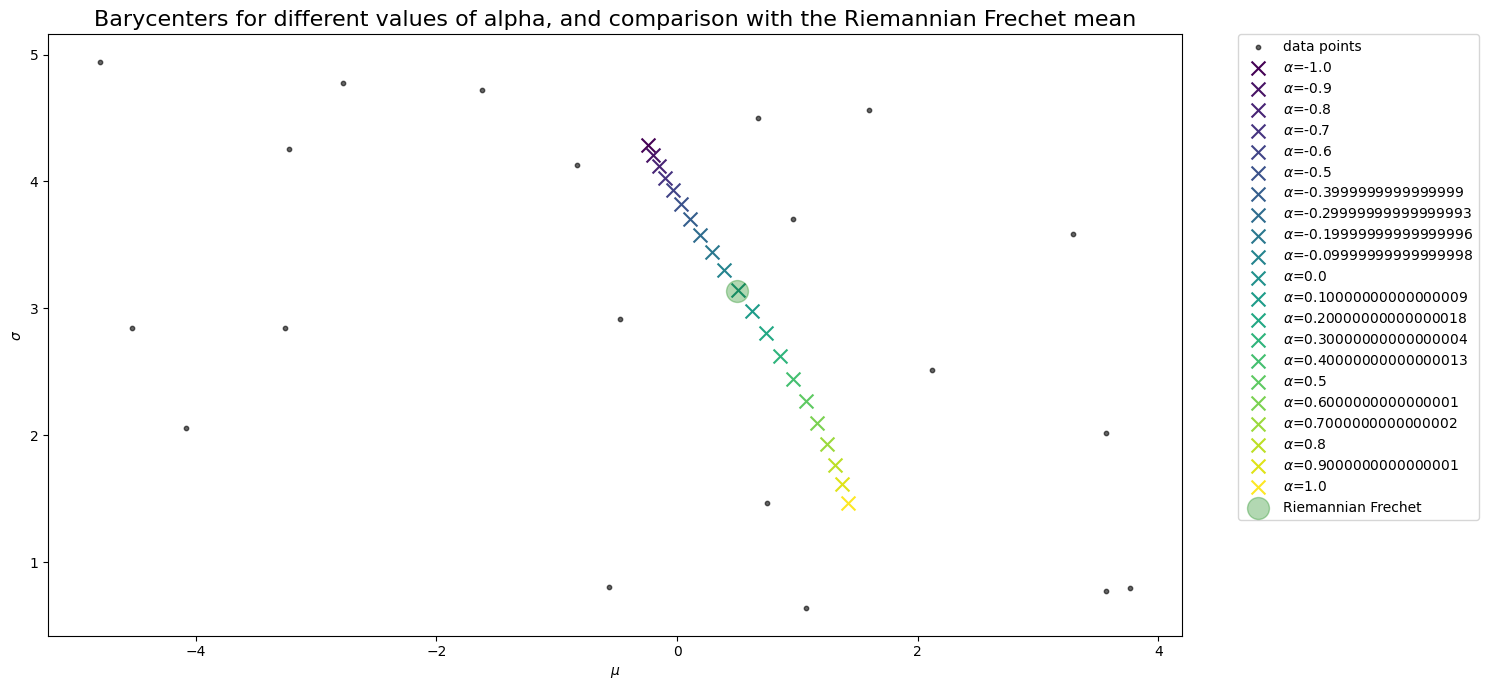

In [9]:
means_random, riemannian_mean_random = generation_means(random_points, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, random_points, means_random, riemannian_mean_random)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


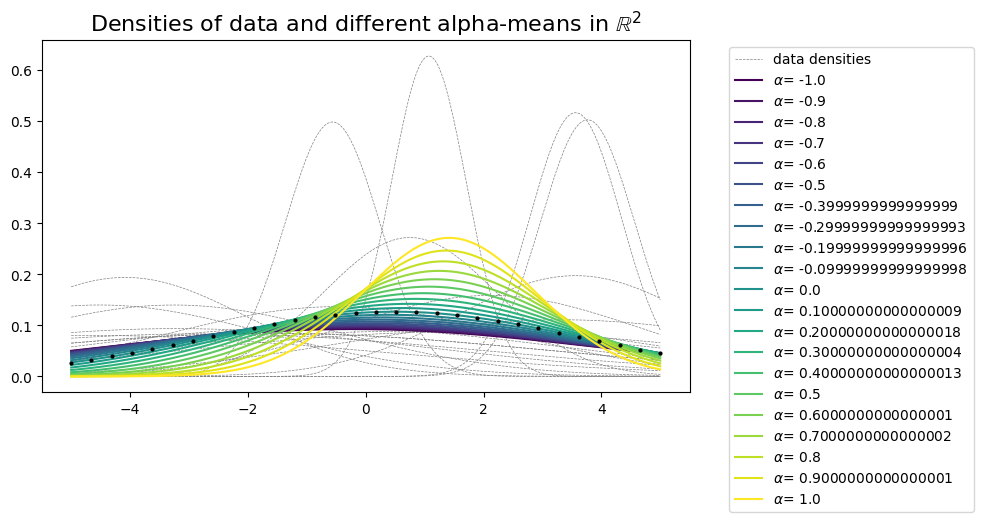

In [10]:
plot_densities(random_points, means_random, alphas, riemannian_mean_random, x_min=-5.0, x_max=5.0)

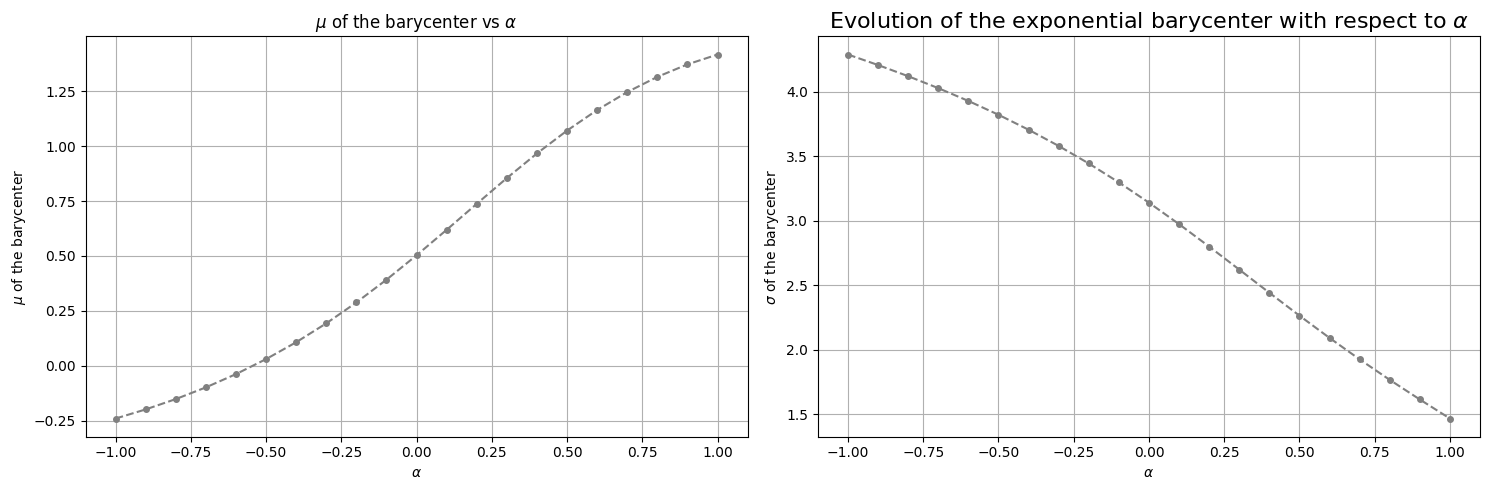

In [11]:
plot_evolution_alpha_barycenter(alphas, means_random)

## We now choose to compare the barycenters of a sphere

### Generation

<Axes: xlabel='X', ylabel='Y'>

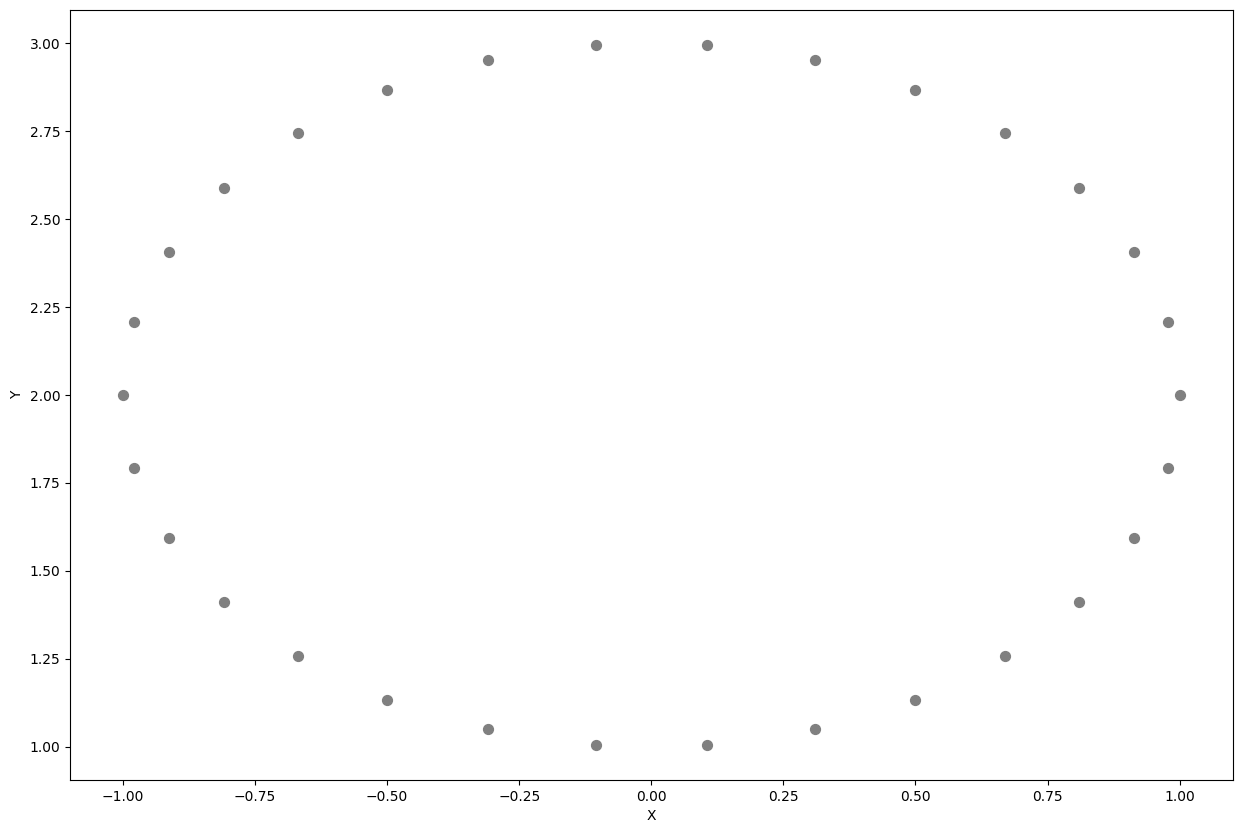

In [8]:

def generation_points_dans_sphere(n_points, seed=0):
    """Generates equidistant points on the disk (0,2). 
     Sampling of angles and generation in polar coordinates
    """
    theta = gs.linspace(0, 2 * gs.pi, n_points, endpoint=False)
    center = gs.array([0.0, 2.0])

    pts = gs.stack([
        center[0] + gs.cos(theta),
        center[1] + gs.sin(theta),
    ], axis=-1)

    return gs.array(pts)

points_sphere= generation_points_dans_sphere(n_points=30, seed=42)

fig, ax = plt.subplots(figsize=(15, 10))
visualization.plot(
        points_sphere,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="gray",
        s=50,
        label="data points",
    )

$\alpha$=-1.0  :  $\mu$=-0.0000,  $\sigma$=2.2361
$\alpha$=-0.5  :  $\mu$=-0.0000,  $\sigma$=2.0936
$\alpha$=0.0  :  $\mu$=-0.0001,  $\sigma$=1.9314
$\alpha$=0.5  :  $\mu$=-0.0000,  $\sigma$=1.7644
$\alpha$=1.0  :  $\mu$=-0.0000,  $\sigma$=1.6119
The $\alpha$=Riemannian Frechet  is  (0.0020,1.9315) and the $\alpha = 0$ mean is (-0.0001,1.9314)


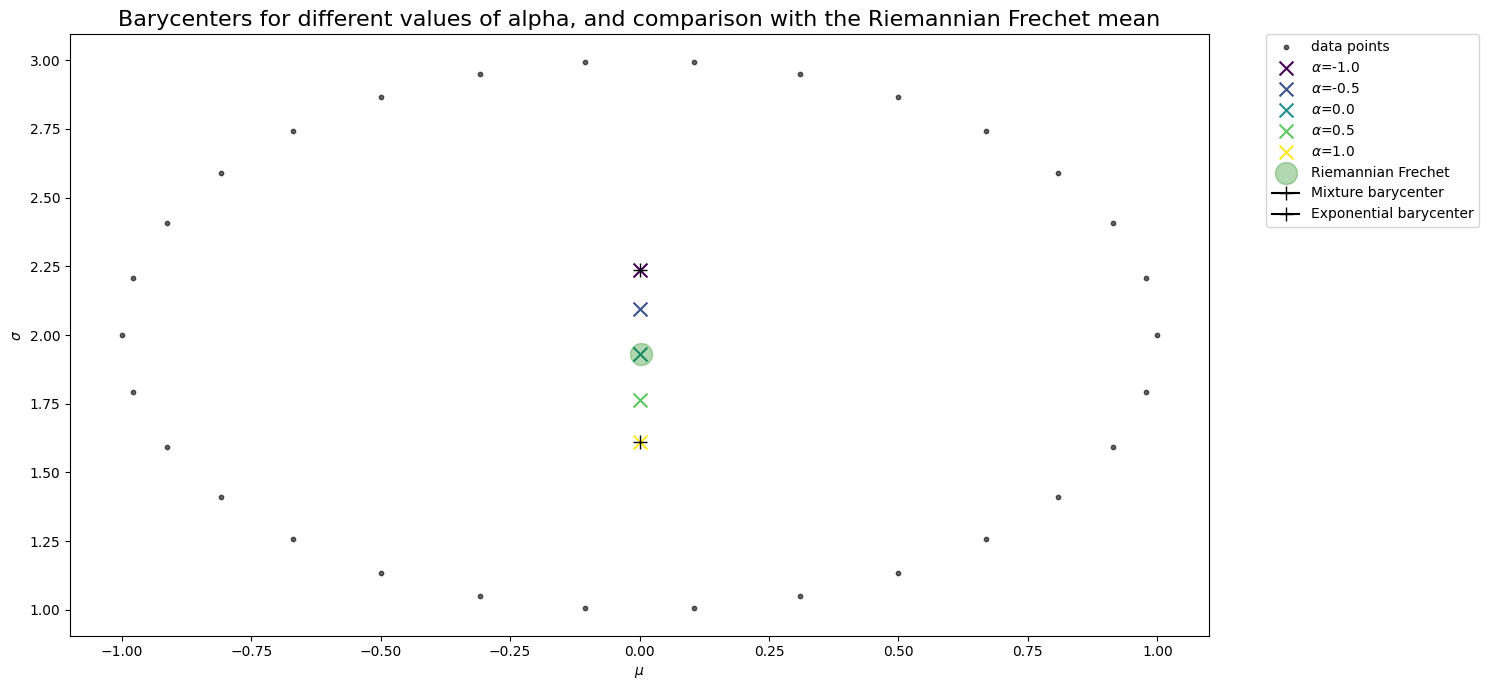

In [9]:
means_sphere, riemannian_mean_sphere = generation_means(points_sphere, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points_sphere, means_sphere, riemannian_mean_sphere)

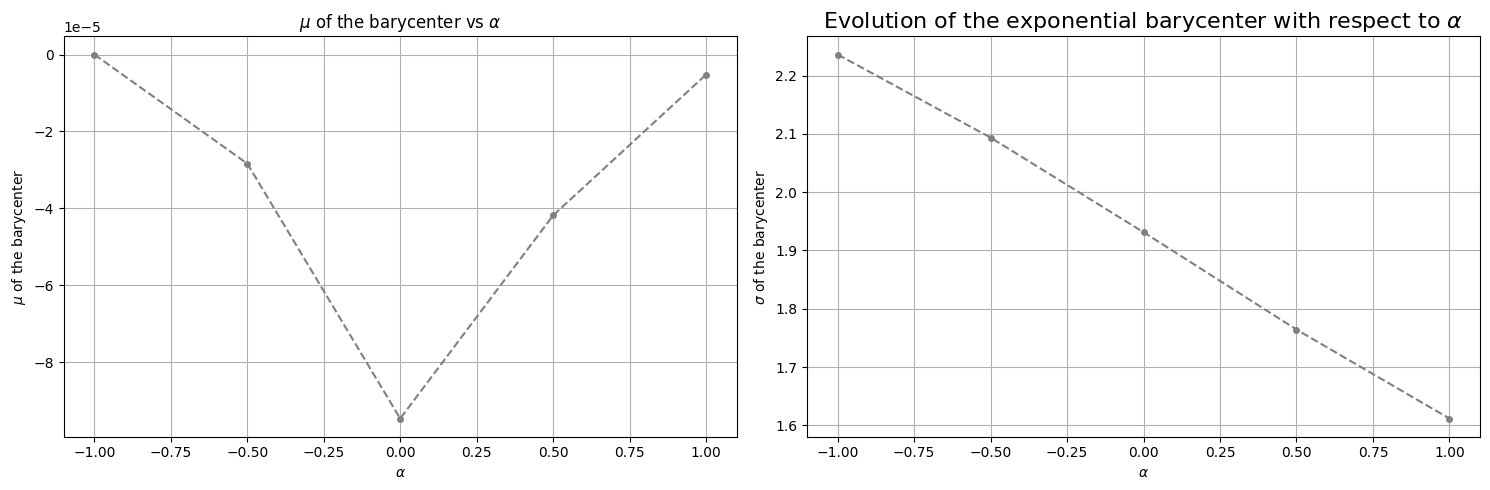

In [10]:
plot_evolution_alpha_barycenter(alphas, means_sphere)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


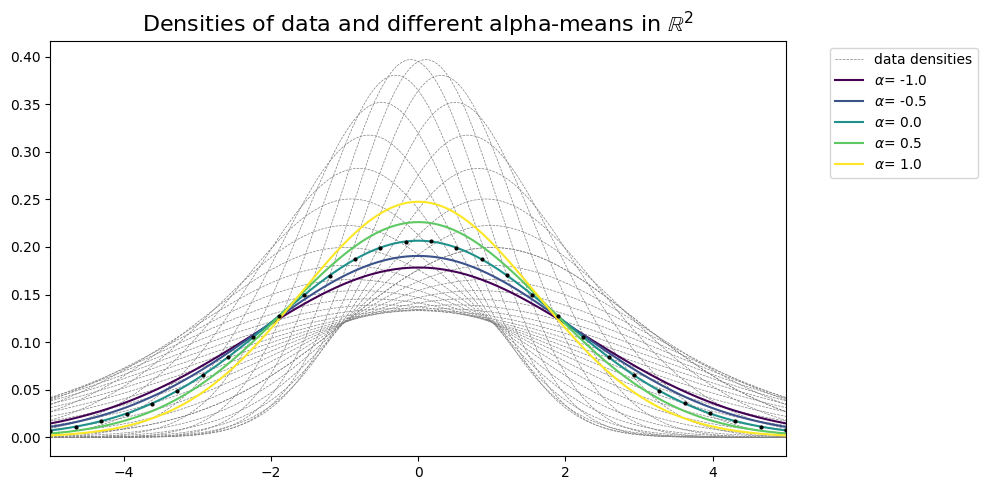

In [11]:
plot_densities(points_sphere, means_sphere, alphas, riemannian_mean_sphere, x_min=-5.0, x_max=5.0)

## We take away the symetry of $\mu$ in the sphere

30
90


<Axes: xlabel='X', ylabel='Y'>

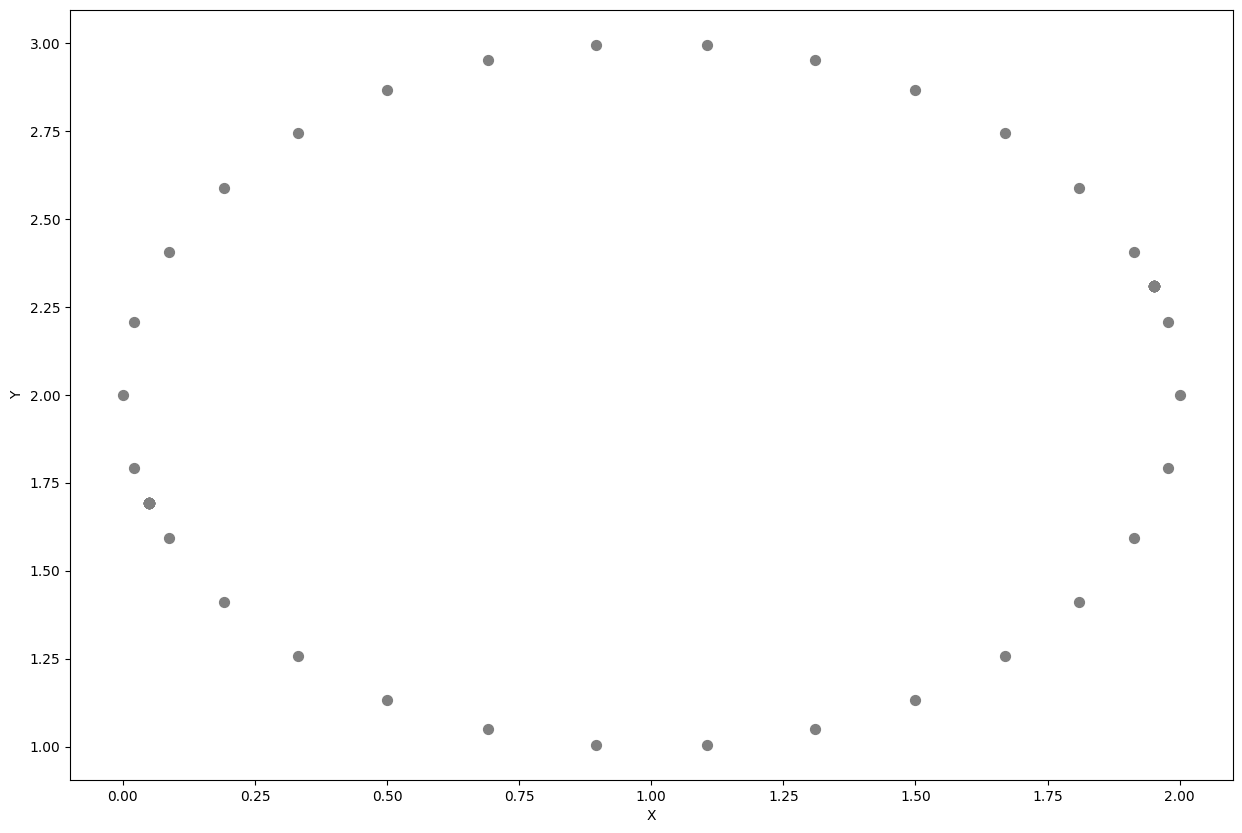

In [12]:
def generation_points_dans_sphere_asym(n_points, seed=0):
    """Generates equidistant points on the disk (0,2). 
     Sampling of angles and generation in polar coordinates
    """
    theta = gs.linspace(0, 2 * gs.pi, n_points, endpoint=False)
    theta_trap = 0.1 * gs.pi
    theta_trap_bis = 0.1 * gs.pi + gs.pi
    print(len(theta))
    center = gs.array([1.0, 2.0])

    pts = gs.stack([
        center[0] + gs.cos(theta),
        center[1] + gs.sin(theta),
    ], axis=-1)

    pts_supp = gs.stack([[center[0]+gs.cos(theta_trap), center[1]+gs.sin(theta_trap)] for i in range(n_points)])
    pts_supp_bis = gs.stack([[center[0]+gs.cos(theta_trap_bis), center[1]+gs.sin(theta_trap_bis)] for i in range(n_points)])
    pts = gs.concatenate([pts, pts_supp])
    pts = gs.concatenate([pts, pts_supp_bis])

    print(len(pts))
    return gs.array(pts)

points_sphere_asym= generation_points_dans_sphere_asym(n_points=30, seed=42)

fig, ax = plt.subplots(figsize=(15, 10))
visualization.plot(
        points_sphere_asym,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="gray",
        s=50,
        label="data points",
    )

$\alpha$=-1.0  :  $\mu$=1.0000,  $\sigma$=2.2361
$\alpha$=-0.5  :  $\mu$=0.9533,  $\sigma$=2.1403
$\alpha$=0.0  :  $\mu$=0.9050,  $\sigma$=2.0337
$\alpha$=0.5  :  $\mu$=0.8625,  $\sigma$=1.9197
$\alpha$=1.0  :  $\mu$=0.8328,  $\sigma$=1.8036
The $\alpha$=Riemannian Frechet  is  (0.8838,2.0384) and the $\alpha = 0$ mean is (0.9050,2.0337)


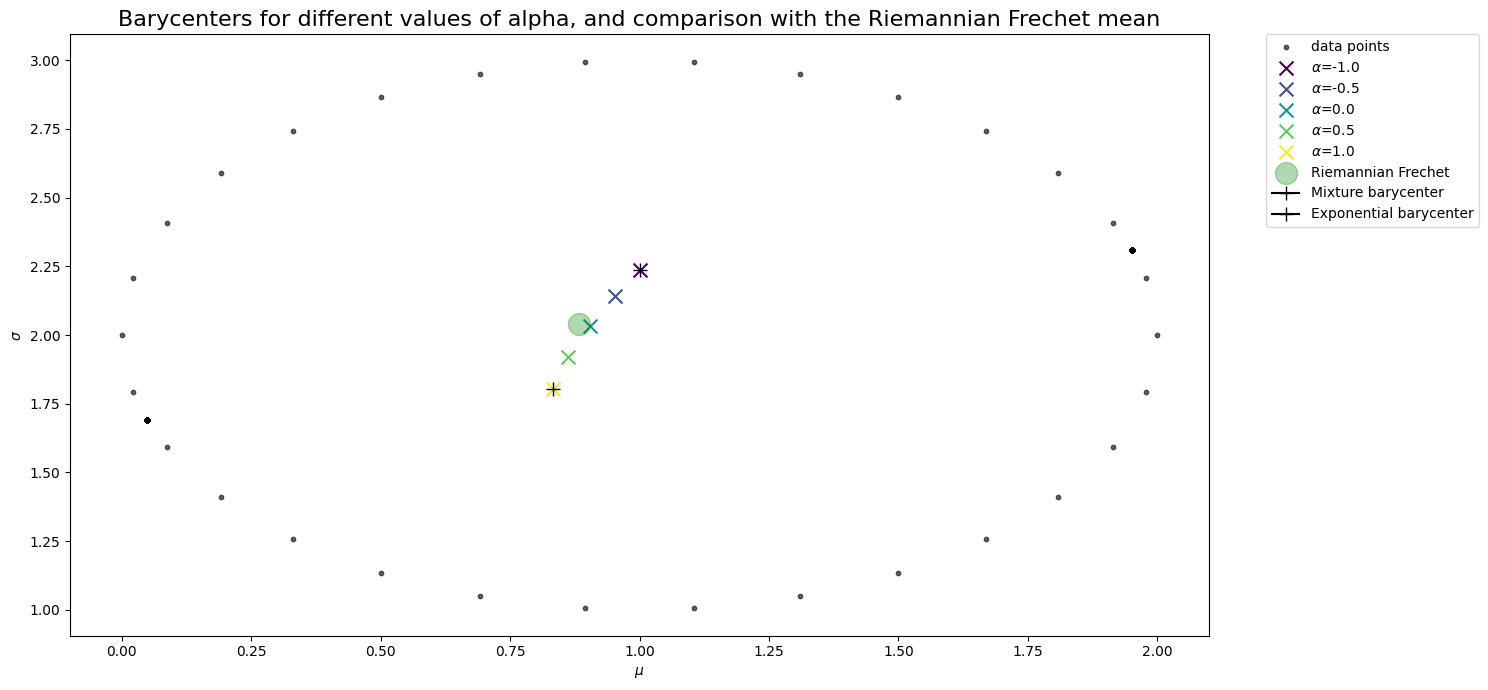

In [13]:
means_sphere_asym, riemannian_mean_sphere_asym = generation_means(points_sphere_asym, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points_sphere_asym, means_sphere_asym, riemannian_mean_sphere_asym)

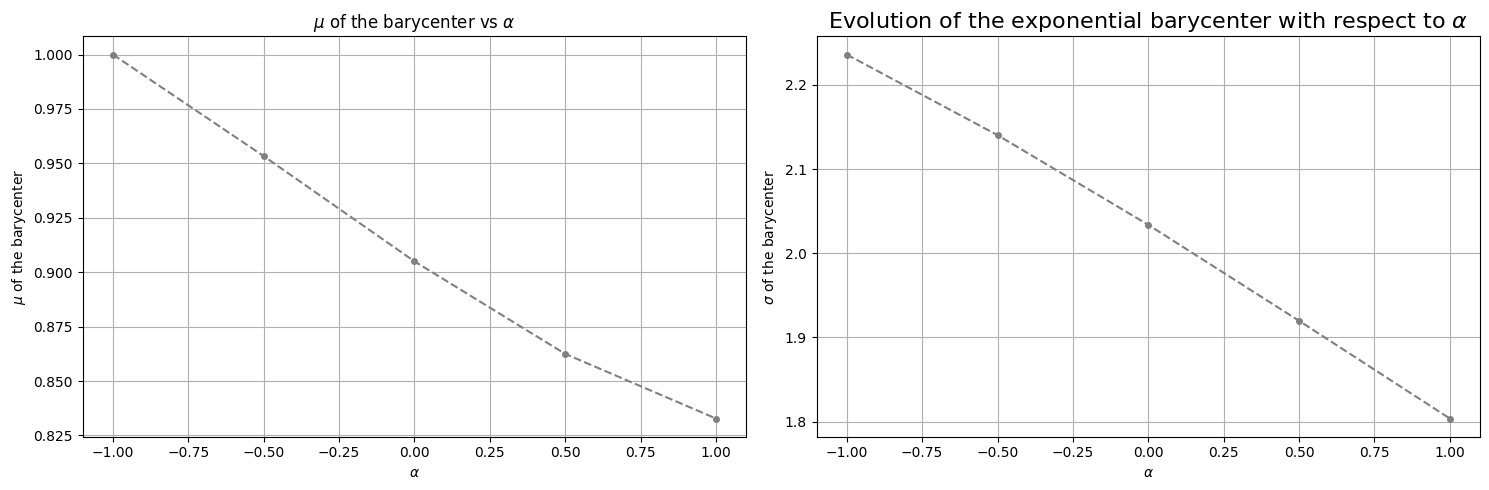

In [14]:
plot_evolution_alpha_barycenter(alphas, means_sphere_asym)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


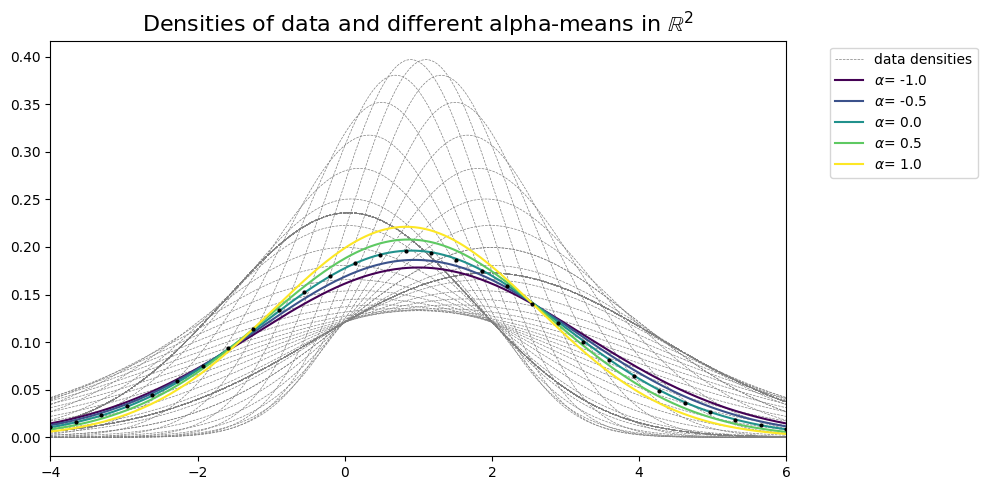

In [15]:
plot_densities(points_sphere_asym, means_sphere_asym, alphas, riemannian_mean_sphere_asym, x_min=-4.0, x_max=6.0)

## verif geod

$\alpha$=-1.0  :  $\mu$=2.5000,  $\sigma$=2.9581
$\alpha$=-0.5  :  $\mu$=2.1976,  $\sigma$=2.6339
$\alpha$=0.0  :  $\mu$=1.6666,  $\sigma$=2.1858
$\alpha$=0.5  :  $\mu$=1.1498,  $\sigma$=1.6723
$\alpha$=1.0  :  $\mu$=1.0000,  $\sigma$=1.2649
The $\alpha$=Riemannian Frechet  is  (1.6667,2.1858) and the $\alpha = 0$ mean is (1.6666,2.1858)


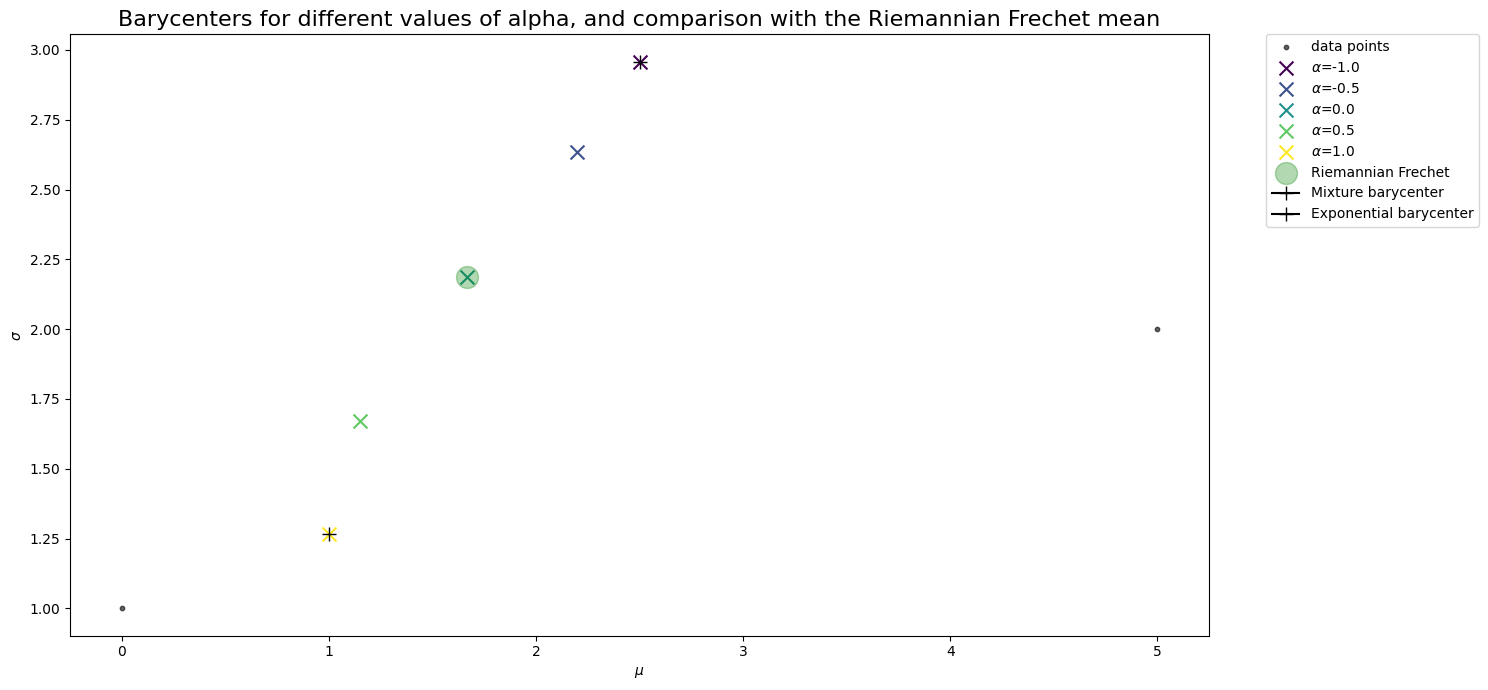

In [16]:
point_1 = gs.array([[0.0,1.0]])
point_2 = gs.array([[5.0,2.0]])
points= gs.concatenate([point_1, point_2])
means_geod, riemannian_mean_geod = generation_means(points, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points, means_geod, riemannian_mean_geod)


## Others

### vertical and horizntal alignments

In [17]:
mu_vals = np.linspace(-2, 2, 20)
sigma_val = 1.0
points_horizontal = np.array([[mu, sigma_val] for mu in mu_vals])
# gaussiennes de même largeur, centrées à des endroits différents

$\alpha$=-1.0  :  $\mu$=0.0000,  $\sigma$=1.5728
$\alpha$=-0.5  :  $\mu$=-0.0000,  $\sigma$=1.4354
$\alpha$=0.0  :  $\mu$=0.0000,  $\sigma$=1.3003
$\alpha$=0.5  :  $\mu$=-0.0000,  $\sigma$=1.1609
$\alpha$=1.0  :  $\mu$=0.0000,  $\sigma$=1.0000
The $\alpha$=Riemannian Frechet  is  (0.0000,1.2982) and the $\alpha = 0$ mean is (0.0000,1.3003)


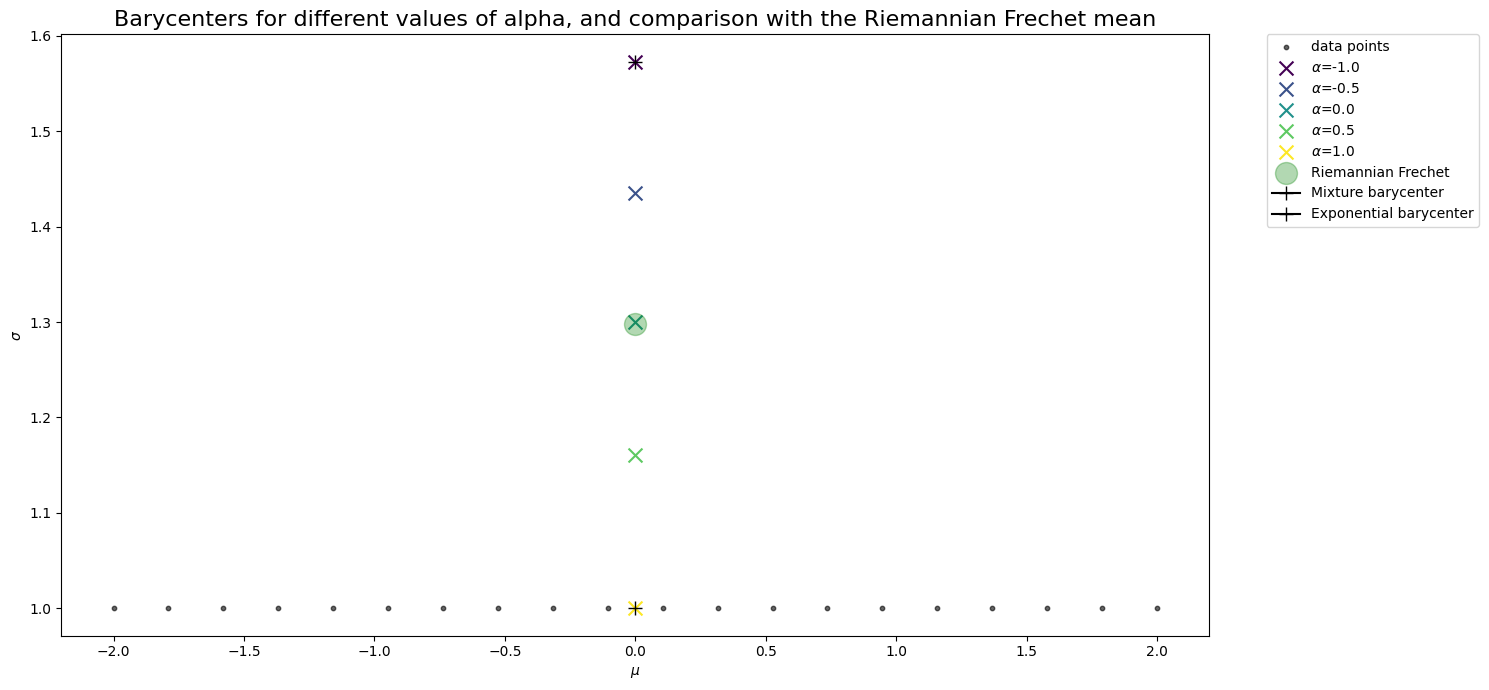

In [18]:
means_horizontal, riemannian_mean_horizontal = generation_means(points_horizontal, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points_horizontal, means_horizontal, riemannian_mean_horizontal)

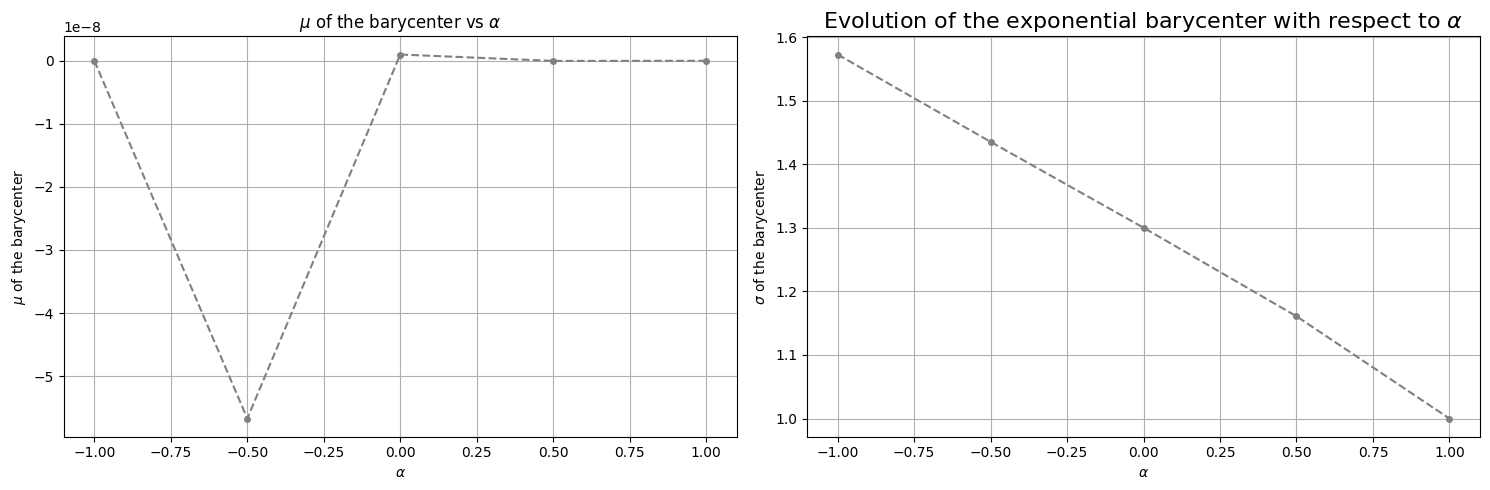

In [19]:
plot_evolution_alpha_barycenter(alphas, means_horizontal)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


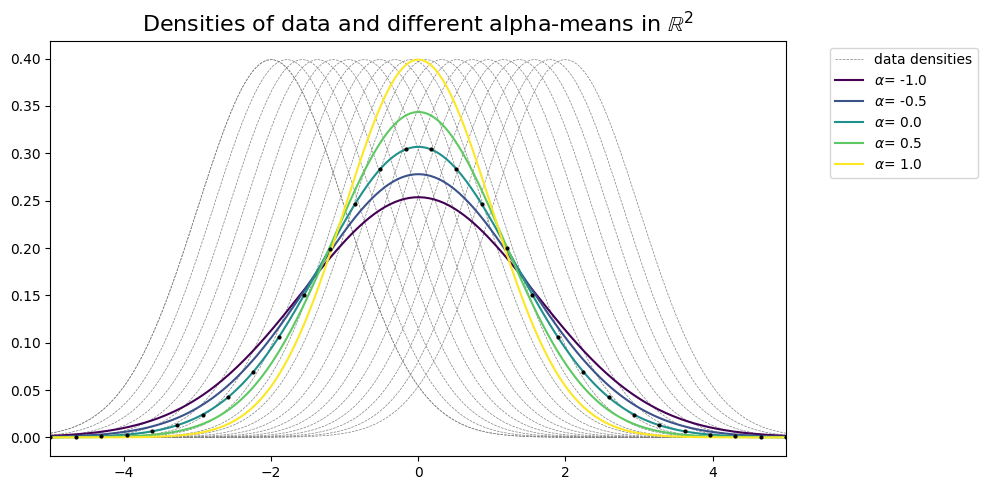

In [20]:
plot_densities(points_horizontal, means_horizontal, alphas, riemannian_mean_horizontal, x_min=-5.0, x_max=5.0)

In [21]:
mu_val = 0.0
sigma_vals = np.linspace(0.5, 2.5, 20)
points_vertical = np.array([[mu_val, sigma] for sigma in sigma_vals])
# → gaussiennes toutes centrées en 0 mais de plus en plus étalées

$\alpha$=-1.0  :  $\mu$=0.0000,  $\sigma$=1.6182
$\alpha$=-0.5  :  $\mu$=0.0000,  $\sigma$=1.5000
$\alpha$=0.0  :  $\mu$=0.0000,  $\sigma$=1.3602
$\alpha$=0.5  :  $\mu$=0.0000,  $\sigma$=1.2105
$\alpha$=1.0  :  $\mu$=0.0000,  $\sigma$=1.0716
The $\alpha$=Riemannian Frechet  is  (0.0000,1.3602) and the $\alpha = 0$ mean is (0.0000,1.3602)


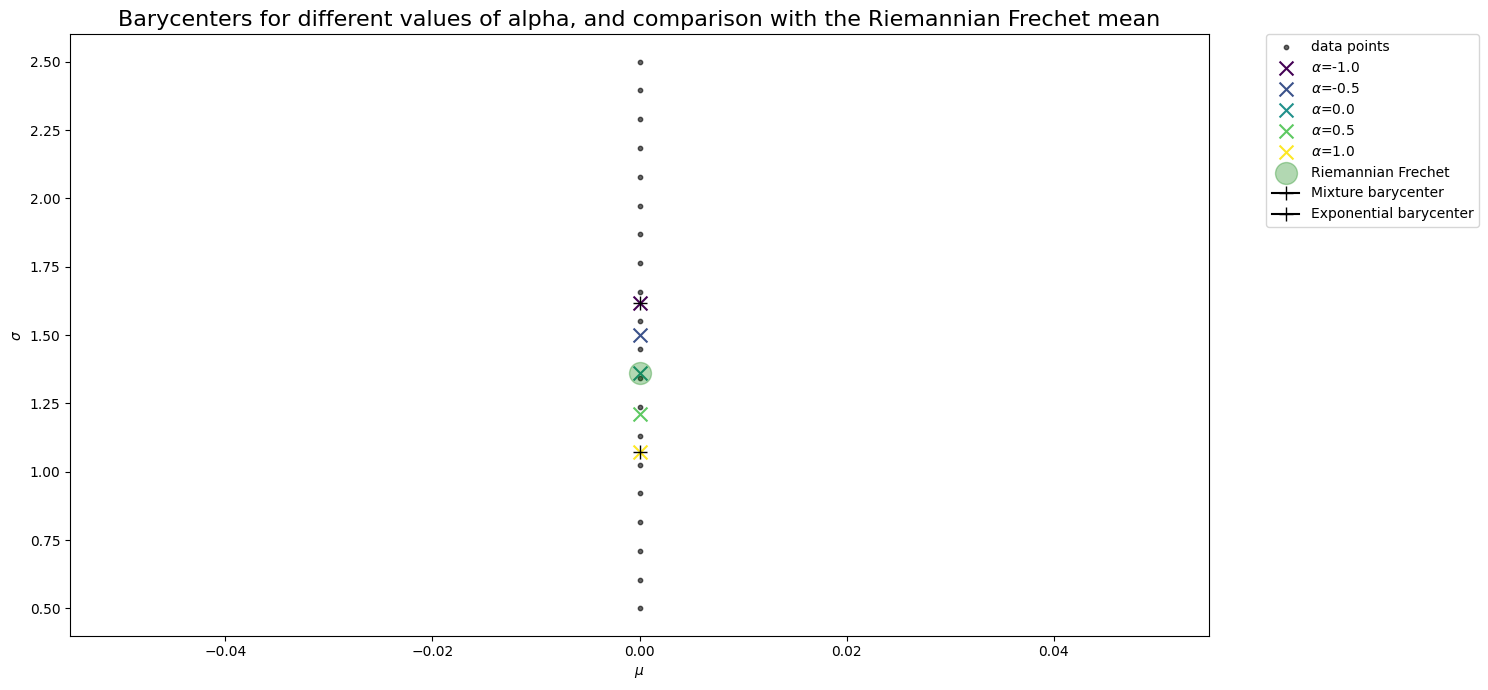

In [22]:
means_vertical, riemannian_mean_vertical = generation_means(points_vertical, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points_vertical, means_vertical, riemannian_mean_vertical)

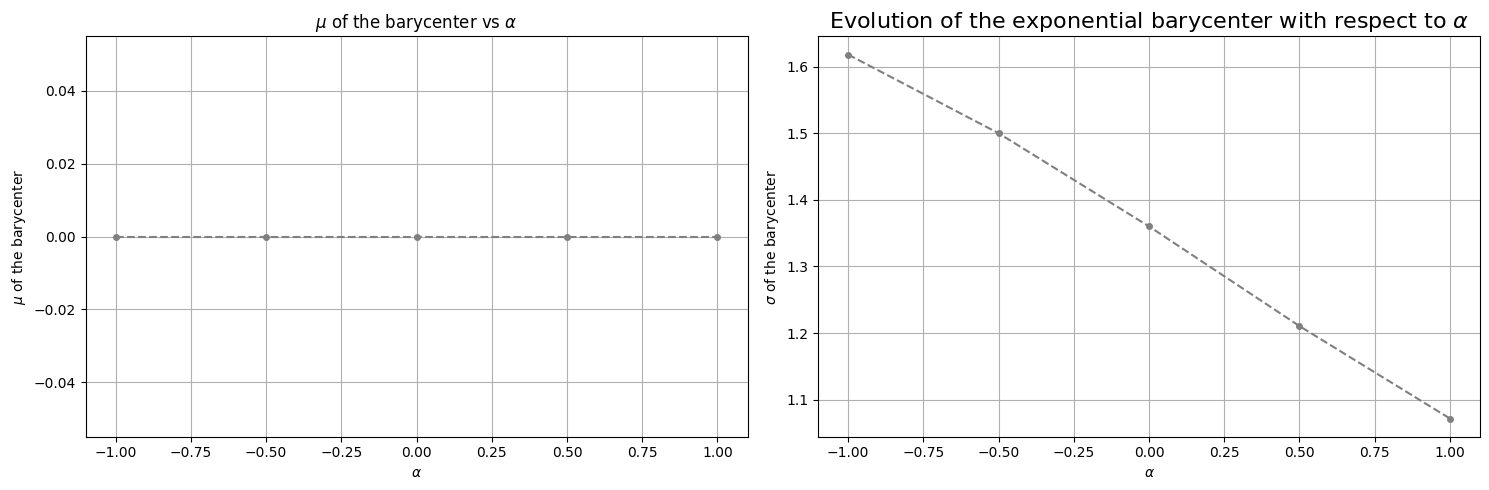

In [23]:
plot_evolution_alpha_barycenter(alphas, means_vertical)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


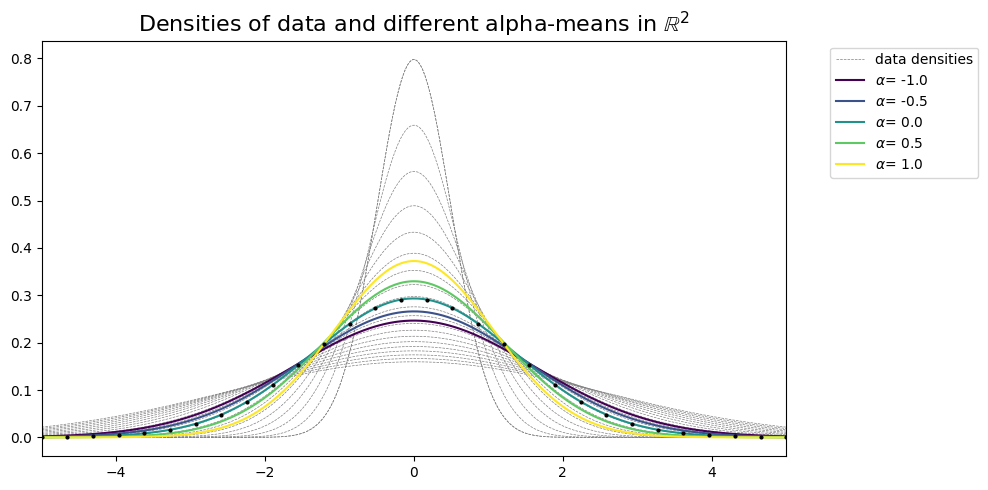

In [24]:
plot_densities(points_vertical, means_vertical, alphas, riemannian_mean_vertical, x_min=-5.0, x_max=5.0)

### ellipse

In [25]:
t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
a, b = 1.5, 0.8      # demi-axes
mu_center, sigma_center = 0.0, 1.5
points_ellipse = np.array([
    [mu_center + a * np.cos(ti), sigma_center + b * np.sin(ti)]
    for ti in t
])
# attention : garder sigma > 0, donc sigma_center > b
# ellipse centrée en (0,1.5) avec demi-axes a=1.5 et b=0.8



$\alpha$=-1.0  :  $\mu$=-0.0000,  $\sigma$=1.9223
$\alpha$=-0.5  :  $\mu$=-0.0000,  $\sigma$=1.7618
$\alpha$=0.0  :  $\mu$=0.0000,  $\sigma$=1.5700
$\alpha$=0.5  :  $\mu$=0.0000,  $\sigma$=1.3628
$\alpha$=1.0  :  $\mu$=-0.0000,  $\sigma$=1.1670
The $\alpha$=Riemannian Frechet  is  (0.0038,1.5720) and the $\alpha = 0$ mean is (0.0000,1.5700)


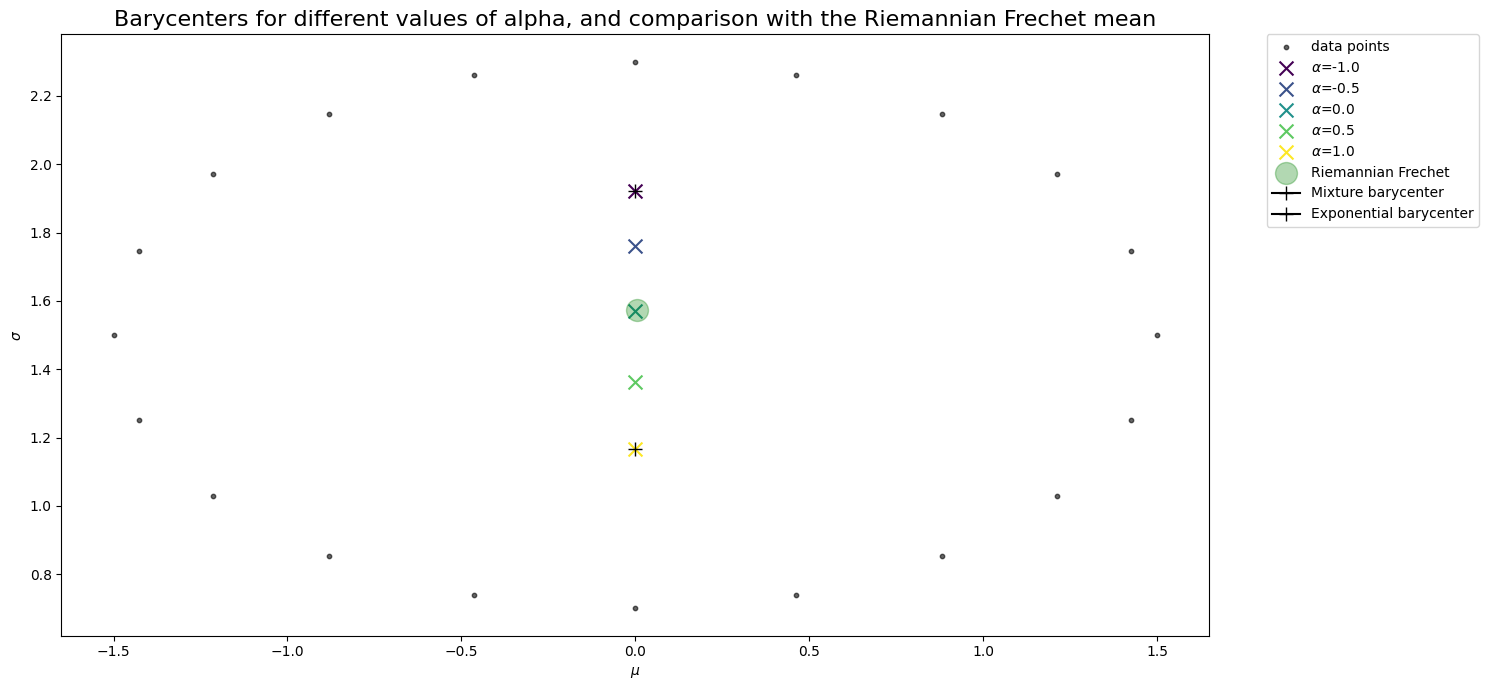

In [26]:
means_ellipse, riemannian_mean_ellipse = generation_means(points_ellipse, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points_ellipse, means_ellipse, riemannian_mean_ellipse)

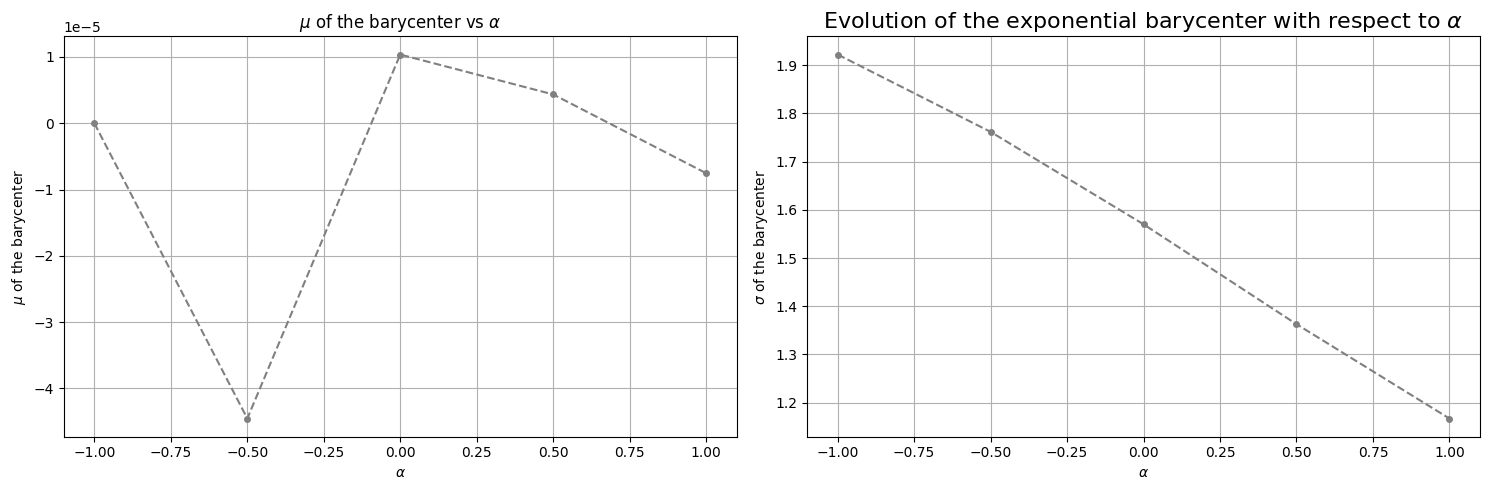

In [27]:
plot_evolution_alpha_barycenter(alphas, means_ellipse)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


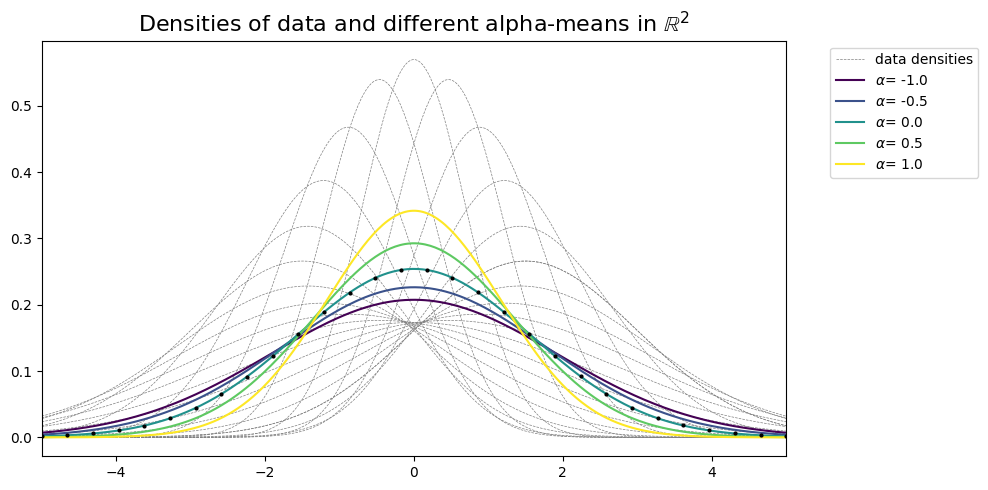

In [28]:
plot_densities(points_ellipse, means_ellipse, alphas, riemannian_mean_ellipse, x_min=-5.0, x_max=5.0)

### diagonal

In [29]:
# points sur la diagonale mu=sigma
mu_vals = np.linspace(-2, 2, 20)
sigma_vals = np.linspace(0.5, 2.5, 20)
points_diag = np.array([[mu, sigma] for mu, sigma in zip(mu_vals, sigma_vals)])
# plus on s'éloigne à droite, plus la gaussienne est large


$\alpha$=-1.0  :  $\mu$=0.0000,  $\sigma$=2.0229
$\alpha$=-0.5  :  $\mu$=-0.2100,  $\sigma$=1.8367
$\alpha$=0.0  :  $\mu$=-0.5030,  $\sigma$=1.6007
$\alpha$=0.5  :  $\mu$=-0.8344,  $\sigma$=1.3258
$\alpha$=1.0  :  $\mu$=-1.1027,  $\sigma$=1.0716
The $\alpha$=Riemannian Frechet  is  (-0.5010,1.5987) and the $\alpha = 0$ mean is (-0.5030,1.6007)


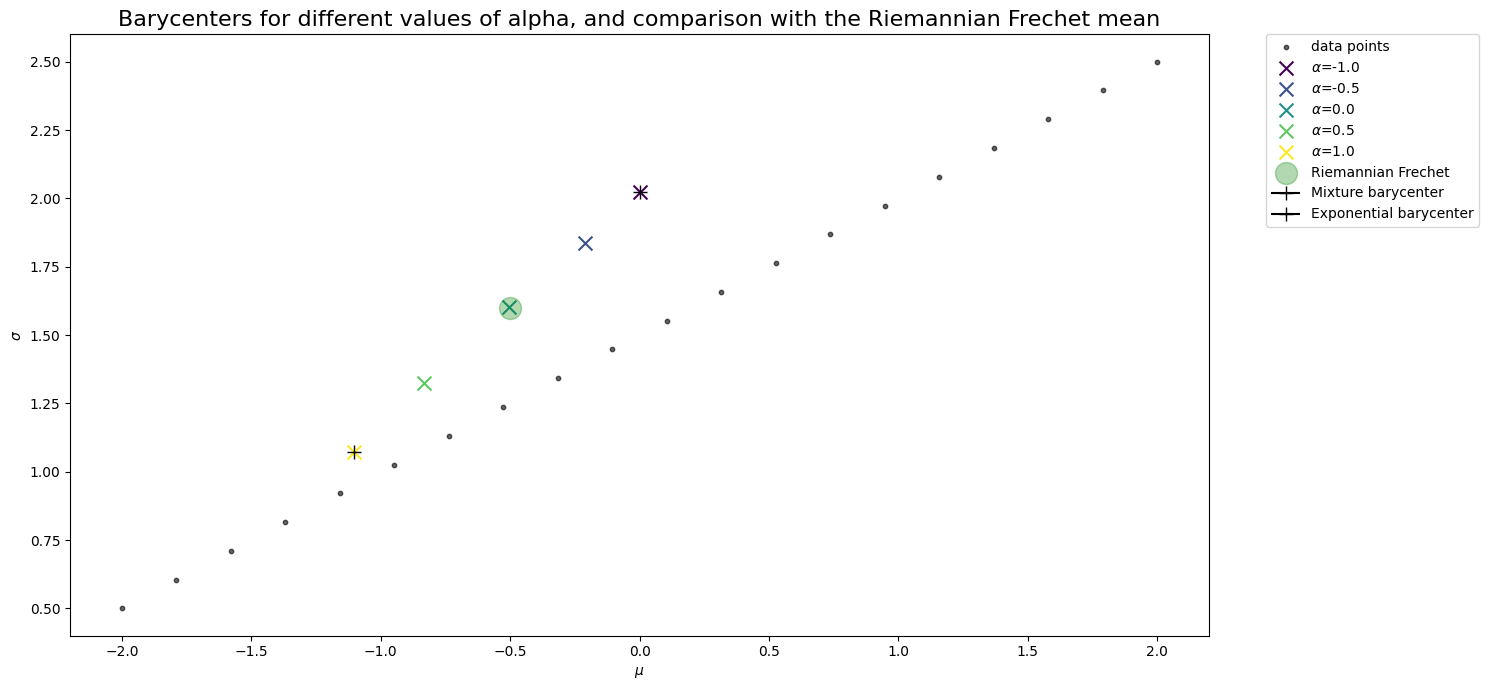

In [30]:
means_diag, riemannian_mean_diag = generation_means(points_diag, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points_diag, means_diag, riemannian_mean_diag)

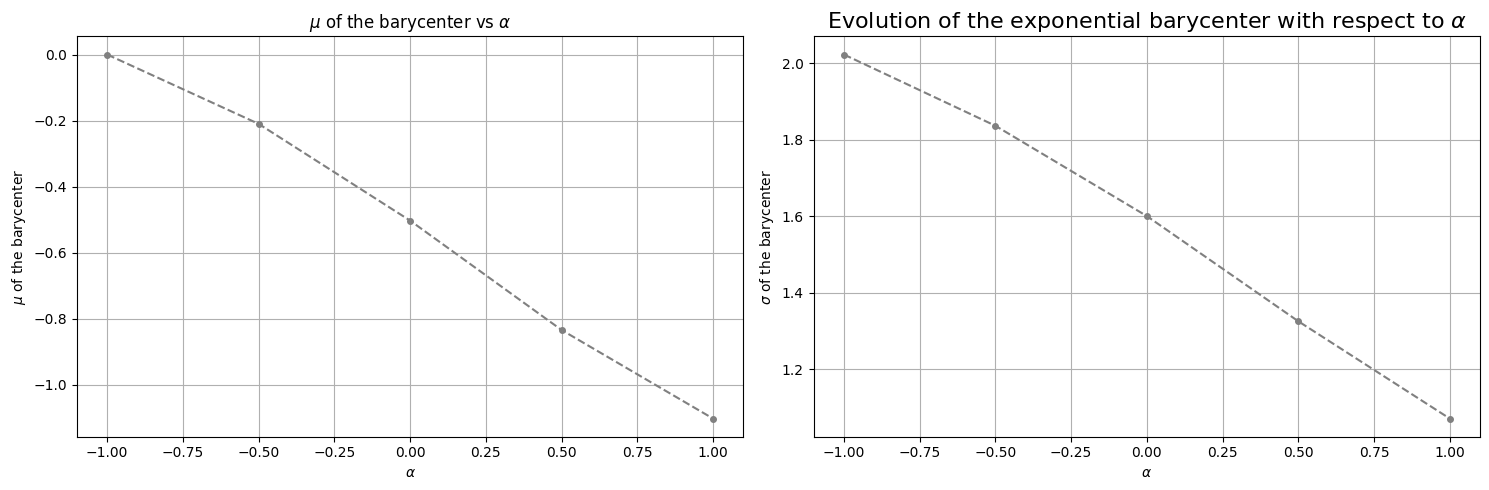

In [31]:
plot_evolution_alpha_barycenter(alphas, means_diag)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


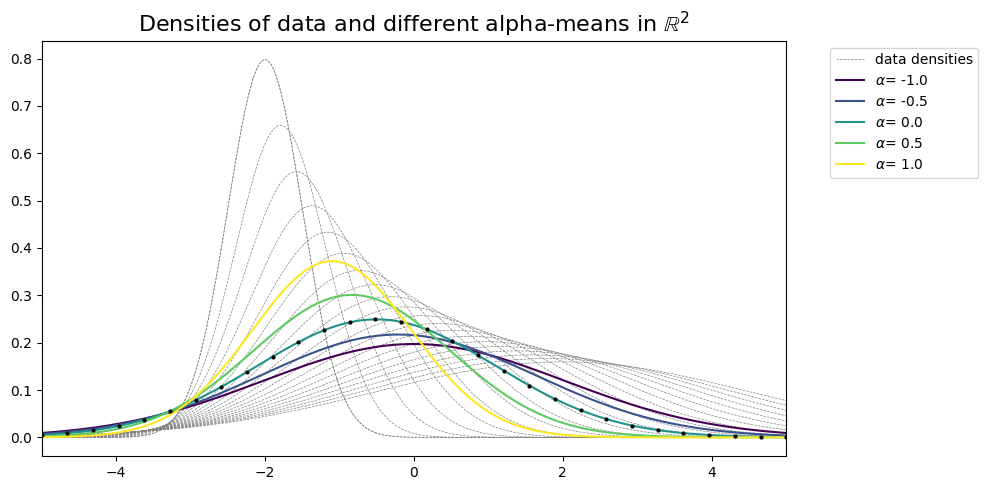

In [32]:
plot_densities(points_diag, means_diag, alphas, riemannian_mean_diag, x_min=-5.0, x_max=5.0)

### grille

In [33]:
# Grille régulière

mus = np.linspace(-1, 1, 3)
sigmas = np.linspace(0.5, 1.5, 3)
points_grid = np.array([[mu, sigma] for mu in mus for sigma in sigmas])


$\alpha$=-1.0  :  $\mu$=0.0000,  $\sigma$=1.3540
$\alpha$=-0.5  :  $\mu$=-0.0000,  $\sigma$=1.2319
$\alpha$=0.0  :  $\mu$=0.0000,  $\sigma$=1.0869
$\alpha$=0.5  :  $\mu$=0.0000,  $\sigma$=0.9224
$\alpha$=1.0  :  $\mu$=0.0000,  $\sigma$=0.7423
The $\alpha$=Riemannian Frechet  is  (-0.0034,1.0816) and the $\alpha = 0$ mean is (0.0000,1.0869)


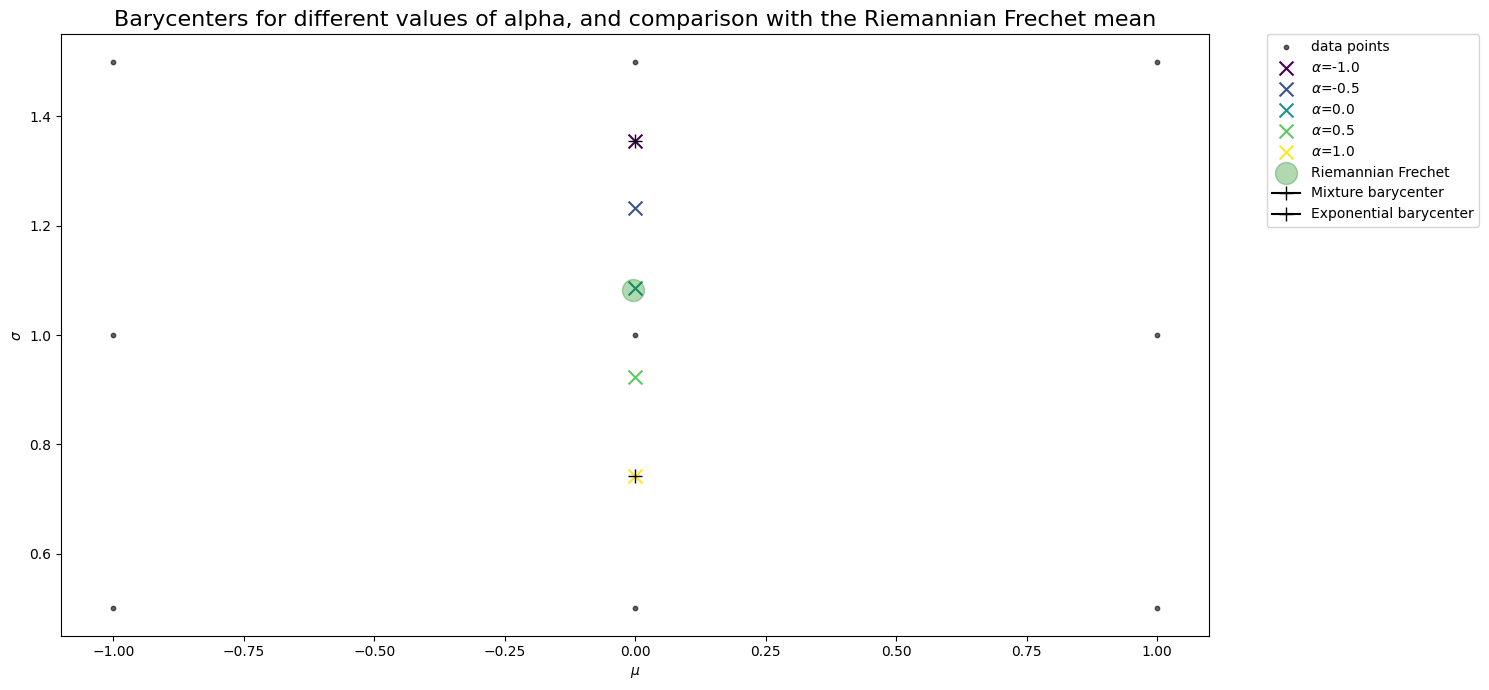

In [34]:
means_grid, riemannian_mean_grid = generation_means(points_grid, alphas, riemannian_manifold)
plot_alpha_barycenters(alphas, points_grid, means_grid, riemannian_mean_grid)

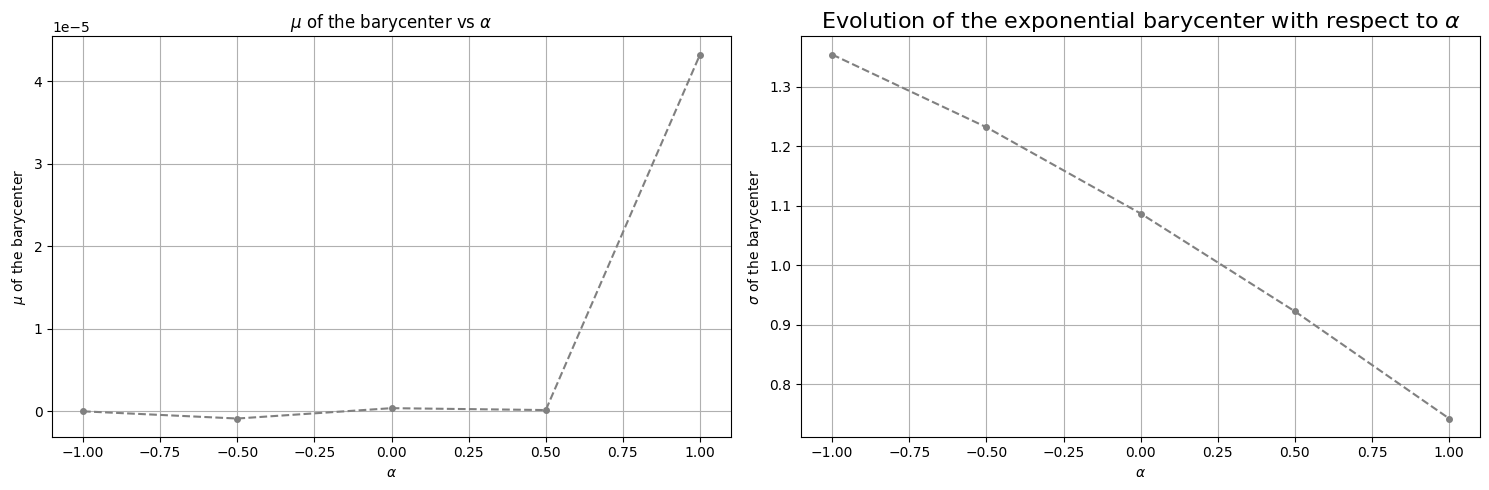

In [35]:
plot_evolution_alpha_barycenter(alphas, means_grid)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


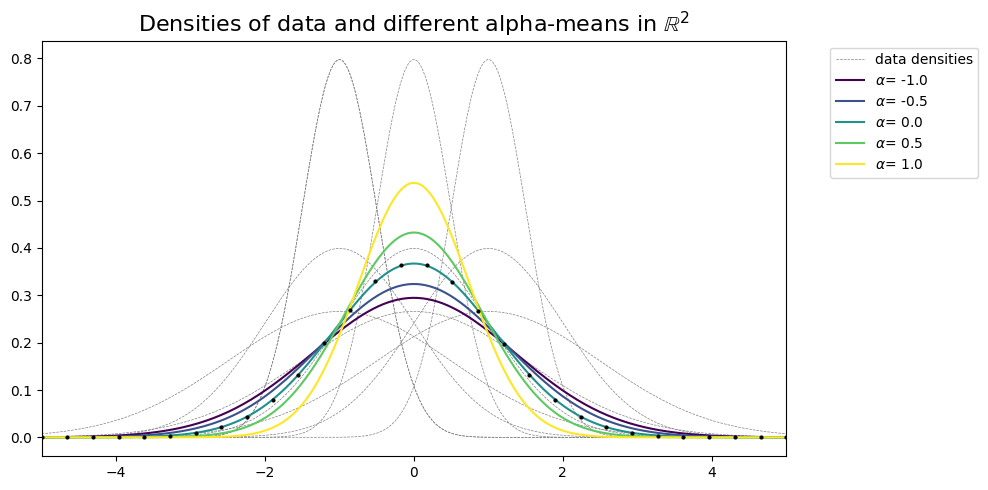

In [36]:
plot_densities(points_grid, means_grid, alphas, riemannian_mean_grid, x_min=-5.0, x_max=5.0)

### triangle

In [37]:
x = random.uniform(-5, 5)
(mu_1, sigma_1) = (0.0+x,1.0)
(mu_2, sigma_2) = (2.0+x,1.0)
(mu_3, sigma_3) = (1.0+x,3.0)
points_triangle= gs.array([[mu_1, sigma_1], [mu_2, sigma_2], [mu_3, sigma_3]])

# Tests de comportement

In [69]:
def distribution_symetrique(nombre_points, mu):
    mus    = [random.uniform(-5,5) for _ in range(nombre_points)]
    sigmas = [random.uniform(0.5,5.0) for _ in range(nombre_points)]
    sym_mus = [2*mu - m for m in mus]
    random_points = gs.array(np.stack([mus, sigmas], axis=-1))
    sym_points = gs.array(np.stack([sym_mus, sigmas], axis=-1))
    points = gs.concatenate([random_points, sym_points], axis=0)
    print(points)
    print(gs.concatenate([random_points, sym_points], axis=-1))
    return gs.array(points)

def distribution_centralisee_sym(nombre_points, mu, alphas, riemannian_manifold):
    mus    = [random.uniform(-5,5) for _ in range(nombre_points)]
    sigmas = [random.uniform(0.5,5.0) for _ in range(nombre_points)]
    sym_mus = [2*mu - m for m in mus]
    random_points = gs.array(np.stack([mus, sigmas], axis=-1))
    sym_points = gs.array(np.stack([sym_mus, sigmas], axis=-1))
    print(mus)
    print(sym_mus)

    print(random_points)
    print(sym_points)

    points = gs.concatenate([random_points, sym_points], axis=0)
    print(points)

    points_centered_dict = {}
    
    for alpha in alphas:
        points_centered = []
        for i in range(len(random_points)):
            new_points = gs.array([random_points[i], sym_points[i]])
            means_dict, _ = generation_means(new_points, [float(alpha)], riemannian_manifold)
            points_centered.append(means_dict[float(alpha)])
            print(points_centered)
        
        points_centered = gs.array(points_centered)
        points_centered_dict[float(alpha)] = points_centered
        
    
    return points, points_centered_dict


In [75]:
alphas = [-1.0, -0.5, 0.0, 0.5, 1.0]
points, points_centered_dict = distribution_centralisee_sym(nombre_points=2, mu=0.0, alphas=alphas, riemannian_manifold=riemannian_manifold)

[1.9607682092875978, -0.3685554067381327]
[-1.9607682092875978, 0.3685554067381327]
[[ 1.96076821  0.68502831]
 [-0.36855541  1.80707375]]
[[-1.96076821  0.68502831]
 [ 0.36855541  1.80707375]]
[[ 1.96076821  0.68502831]
 [-0.36855541  1.80707375]
 [-1.96076821  0.68502831]
 [ 0.36855541  1.80707375]]
[array([-4.59701721e-15,  2.07702454e+00])]
[array([-4.59701721e-15,  2.07702454e+00]), array([2.62376926e-16, 1.84427349e+00])]
[array([-1.13522153e-05,  1.83104414e+00])]
[array([-1.13522153e-05,  1.83104414e+00]), array([-1.16690157e-08,  1.83504504e+00])]
[array([-2.76018588e-06,  1.54648335e+00])]
[array([-2.76018588e-06,  1.54648335e+00]), array([3.89779841e-08, 1.82576889e+00])]
[array([3.45008898e-05, 1.19600167e+00])]
[array([3.45008898e-05, 1.19600167e+00]), array([-1.41661701e-06,  1.81644757e+00])]
[array([-1.04360964e-14,  6.85028305e-01])]
[array([-1.04360964e-14,  6.85028305e-01]), array([2.62376926e-16, 1.80707375e+00])]


[[ 1.96076821  0.68502831]
 [-0.36855541  1.80707375]
 [-1.96076821  0.68502831]
 [ 0.36855541  1.80707375]]
{-1.0: array([[-4.59701721e-15,  2.07702454e+00],
       [ 2.62376926e-16,  1.84427349e+00]]), -0.5: array([[-1.13522153e-05,  1.83104414e+00],
       [-1.16690157e-08,  1.83504504e+00]]), 0.0: array([[-2.76018588e-06,  1.54648335e+00],
       [ 3.89779841e-08,  1.82576889e+00]]), 0.5: array([[ 3.45008898e-05,  1.19600167e+00],
       [-1.41661701e-06,  1.81644757e+00]]), 1.0: array([[-1.04360964e-14,  6.85028305e-01],
       [ 2.62376926e-16,  1.80707375e+00]])}
alpha=-1.0 : barycenter centered = [-2.16732014e-15  1.96409907e+00], barycenter sym = [-4.59701721e-15  1.96411637e+00]
alpha=-0.5 : barycenter centered = [-5.68495954e-06  1.83304459e+00], barycenter sym = [1.27799067e-10 1.83276730e+00]
alpha=0.0 : barycenter centered = [-1.47643677e-06  1.68033566e+00], barycenter sym = [-5.86716731e-17  1.64804175e+00]
alpha=0.5 : barycenter centered = [2.20118023e-05 1.44233131e+0

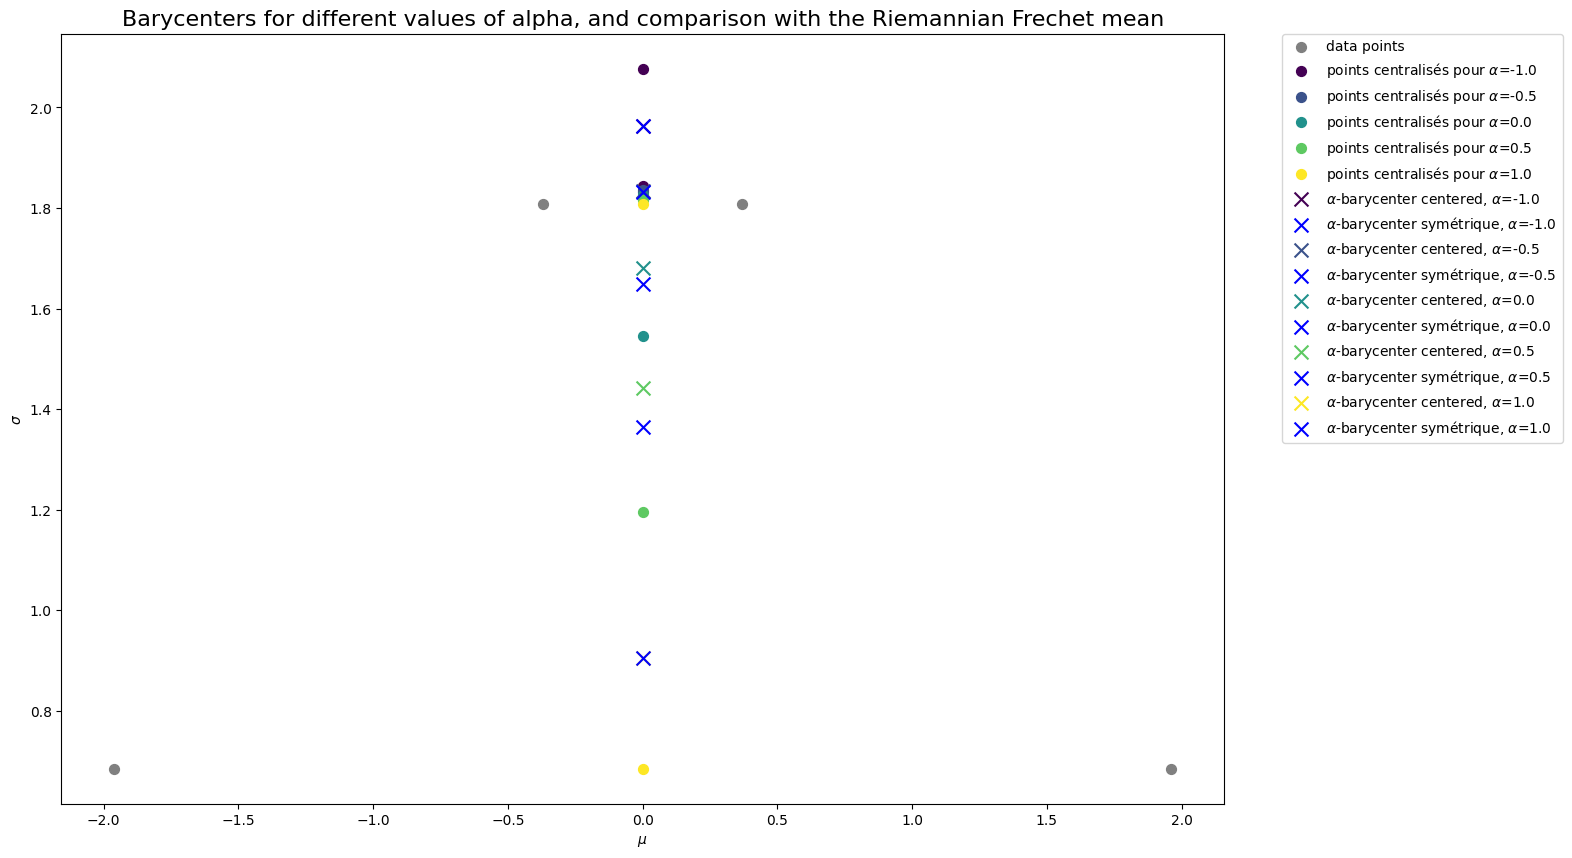

In [76]:
print(points)
print(points_centered_dict)

alpha_barycenter_centered = {}
alpha_barycenter_sym = {}


for alpha in alphas:
    means_dict, _ = generation_means(points_centered_dict[float(alpha)], [float(alpha)], riemannian_manifold)
    alpha_barycenter_centered[float(alpha)] = means_dict[float(alpha)]

for alpha in alphas:
    means_dict, _ = generation_means(points, [float(alpha)], riemannian_manifold)
    alpha_barycenter_sym[float(alpha)] = means_dict[float(alpha)]

for alpha in alphas:
    print(f"alpha={float(alpha)} : barycenter centered = {alpha_barycenter_centered[float(alpha)]}, barycenter sym = {alpha_barycenter_sym[float(alpha)]}")

fig, ax = plt.subplots(figsize=(15, 10))
visualization.plot(
        points,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="gray",
        s=50,
        label="data points",
    )

colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))
for alpha, color in zip(alphas, colors):
    visualization.plot(
        points_centered_dict[float(alpha)],
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color=color,
        s=50,
        label=r"points centralisés pour $\alpha$="+str(float(alpha)),
    )
for alpha,color in zip(alphas, colors):
    visualization.plot(
        alpha_barycenter_centered[float(alpha)][None],
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="x",
        color=color,
        s=100,
        label=r"$\alpha$-barycenter centered, $\alpha$="+str(float(alpha)),
    )
    visualization.plot(
        alpha_barycenter_sym[float(alpha)][None],
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="x",
        color="blue",
        s=100,
        label=r"$\alpha$-barycenter symétrique, $\alpha$="+str(float(alpha)),
    )

ax.set_title("Barycenters for different values of alpha, and comparison with the Riemannian Frechet mean", fontsize=16)
ax.set_xlabel("$\\mu$")
ax.set_ylabel("$\\sigma$")
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)